# Phan loai AAMI 3 lop (N/S/V) - chay LOCAL (adapt tu Colab)  [v25]

**Pipeline:** beat nhieu (256 mau) -> **denoiser haar_sym_lite (FREEZE, thang mV THO)**
-> z-norm SAU denoiser -> CNN -> SE -> pool -> **noi RR(6)**
-> head (**classical MLP** | **quantum VQC + bypass**) -> 3 lop N/S/V.
Inter-patient DS1/DS2. Bo F,Q (hiem + mo ho hinh thai).

## ⚠️ MOI KET QUA PHAI LA TRUNG BINH 5 SEED
Phuong sai seed rat lon: macro-F1 cua 1 lan chay dao dong toi **0.087**. Mot lan chay quantum
tung dat 0.8195 (cao hon ca trung binh classical) nhung trung binh 5 seed chi 0.7897.
**Khong bao gio ket luan tu 1 seed.**

**Ket qua tot nhat (classical ensemble 5 seed):** accuracy **0.9655** · macro-F1 **0.8487** ·
F1 (N .983 / S .663 / V .900) · +P(S) **.660**.
Accuracy, F1(S) va +P(S) deu vuot Mondejar 2019 tren cung giao thuc inter-patient.

**Mac dinh trong code DA LA cau hinh tot nhat** (`sampler_power 0.9`, dropout 0.3,
augment/prior-tune mac dinh TAT) -> lenh train rat gon.

**Chuan bi tren may (local):** code du an da san (thu muc nay co san `src/` va `configs/`).
Neu chua co checkpoint denoiser, dat file `denoise_runs_backup.zip` (chua run `*optimal*`)
vao thu muc goc du an hoac thu muc `Downloads`. Can GPU (khuyen nghi) + Internet (de tai PhysioNet).
Thu tu: 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> **6** -> 7 -> 8 -> 9 -> 10.

## 0. Xac dinh thu muc project (local, khong can mount Drive)

In [1]:
import os

def find_project_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(d, 'src')) and os.path.isdir(os.path.join(d, 'configs')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return None

PROJ = find_project_root(os.getcwd())
assert PROJ, ('Khong tim thay project (can co src/ va configs/). '
              'Hay mo notebook nay tu (hoac ben trong) thu muc goc cua du an.')
os.chdir(PROJ)
print('PROJECT DIR =', PROJ, '| co src/:', os.path.isdir('src'), '| co configs/:', os.path.isdir('configs'))

PROJECT DIR = d:\SPARC Lab\Denoise_ECG_BMELaB | co src/: True | co configs/: True


## 1. Cai thu vien (gom pennylane)

In [2]:
%pip install -q -r requirements.txt
%pip install -q pennylane
import pennylane, sklearn; print('pennylane', pennylane.__version__)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
pennylane 0.45.1


## 2. Tai du lieu PhysioNet (can Internet On)

In [3]:
%pip install -q wfdb
import os, wfdb, requests

# wfdb dung thu vien requests nhung KHONG truyen timeout -> 1 ket noi rot/treo
# se cho VO HAN (da kiem chung: socket.setdefaulttimeout khong an thua voi requests).
# Va lai: ep timeout mac dinh cho MOI request cua 'requests' trong tien trinh nay.
# Co danh dau de KHONG bi bocj chong nhieu lop neu cell nay chay lai nhieu lan (gay RecursionError).
if not getattr(requests.Session.request, '_patched_timeout', False):
    _orig_request = requests.Session.request
    def _request_with_timeout(self, method, url, **kwargs):
        kwargs.setdefault('timeout', 30)
        return _orig_request(self, method, url, **kwargs)
    _request_with_timeout._patched_timeout = True
    requests.Session.request = _request_with_timeout

def dl_with_retry(db, dest, retries=8):
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            wfdb.dl_database(db, dest)
            return
        except Exception as e:
            last_err = e
            print(f'[{db}] loi lan {attempt}/{retries}: {e!r} -> thu lai (file da tai xong se duoc bo qua)')
    raise RuntimeError(f'Tai {db} that bai sau {retries} lan thu: {last_err}')

dl_with_retry('mitdb', os.path.join(PROJ, 'data', 'MITDB'))
dl_with_retry('nstdb', os.path.join(PROJ, 'data', 'NSTDB'))
print('Downloaded.')


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Genera

## 3. Sua config cho may local

In [4]:
import yaml, os
RUNS_DIR = os.path.join(PROJ, 'denoise_runs')   # noi chua run denoiser optimal (local)
cfg = yaml.safe_load(open('configs/default.yaml'))

# --- duong dan local ---
cfg['data']['dataset_root']   = os.path.join(PROJ, 'data')
cfg['data']['processed_root'] = os.path.join(PROJ, 'data', 'processed')
cfg['output_root']            = RUNS_DIR

# --- CAU HINH CHOT (ban tot nhat: macro-F1 0.7393) ---
c = cfg['classification']
c['n_classes'] = 3            # N, S, V (bo F, Q)
c['n_leads']   = 1            # khop denoiser da train tren MLII
c['n_context'] = 1            # KHONG multi-beat (context=3 lam hai lop S)
c['z_norm']    = True         # ap SAU denoiser (trong model)
# VAL CO DINH -> tai lap duoc. auto_val moi lan chay chon record khac -> lech ket qua.
c['auto_val']    = False
c['val_records'] = ['223', '118', '116']   # train: N=39335 S=774 V=3190

yaml.safe_dump(cfg, open('configs/default.yaml', 'w'), sort_keys=False)
print('processed_root =', cfg['data']['processed_root'])
print('classification :', {k: c[k] for k in
      ['n_classes', 'n_leads', 'n_context', 'z_norm', 'auto_val', 'val_records']})

processed_root = d:\SPARC Lab\Denoise_ECG_BMELaB\data\processed
classification : {'n_classes': 3, 'n_leads': 1, 'n_context': 1, 'z_norm': True, 'auto_val': False, 'val_records': ['223', '118', '116']}


## 4. Khoi phuc run denoiser (optimal) tu denoise_runs_backup.zip (local)

In [5]:
import glob, os, zipfile

def find_optimal(root):
    hits = glob.glob(os.path.join(root, '**', '*optimal*'), recursive=True)
    return [p for p in hits if os.path.isdir(p) and os.path.exists(os.path.join(p, 'checkpoint_best.pt'))]

os.makedirs(RUNS_DIR, exist_ok=True)
opt = find_optimal(RUNS_DIR)

if not opt:
    # Chua co san -> tim file denoise_runs_backup*.zip trong project hoac Downloads roi giai nen.
    search_dirs = [PROJ, os.path.join(os.path.expanduser('~'), 'Downloads')]
    bk = []
    for d in search_dirs:
        bk += glob.glob(os.path.join(d, '**', 'denoise_runs_backup*.zip'), recursive=True)
    assert bk, ('Khong thay denoise_runs_backup.zip (da tim trong thu muc project va Downloads). '
                'Hay dat file zip do vao mot trong hai noi tren, hoac tu train denoiser truoc '
                '(xem Train_Denoise_ECG_*.ipynb) de co san checkpoint *optimal* trong ' + RUNS_DIR)
    with zipfile.ZipFile(bk[0]) as z:
        z.extractall(RUNS_DIR)
    opt = find_optimal(RUNS_DIR)
    assert opt, 'Khong tim thay run *optimal* co checkpoint_best.pt sau khi giai nen.'

DENOISE_RUN = opt[0]; print('DENOISE_RUN =', DENOISE_RUN)

DENOISE_RUN = d:\SPARC Lab\Denoise_ECG_BMELaB\denoise_runs\haar_sym_lite_wav-db4_base-32_exp-4_mid-5_loss-mixed_alpha-0.8_optimal


## 5. Sinh du lieu phan loai (beat + nhan AAMI)

In [6]:
%env PYTHONPATH=.
!python -m src.prepare_classification_data --config configs/default.yaml
import pandas as pd, os
df=pd.read_csv(os.path.join(PROJ, 'data', 'processed', 'manifest_cls.csv'))
print('Tong beat:', len(df)); print(df.groupby(['split','label']).size())

env: PYTHONPATH=.



Beats: 100%|██████████| 44/44 [02:48<00:00,  3.84s/it]


VAL CO DINH (auto_val=false) = ['223', '118', '116']
Saved d:\SPARC Lab\Denoise_ECG_BMELaB\data\processed\manifest_cls.csv | tong beat: 99876
Phan bo theo (split, label 0=Normal/1=Abnormal):
split  label
test   0        44241
       1         1837
       2         3220
train  0        39335
       1          774
       2         3190
val    0         6511
       1          170
       2          598
dtype: int64
Tong beat: 99876
split  label
test   0        44241
       1         1837
       2         3220
train  0        39335
       1          774
       2         3190
val    0         6511
       1          170
       2          598
dtype: int64


## 6. Train **4 cau hinh × 5 seed** (toan bo thi nghiem phan loai)

| | Cau hinh | Thu muc | Vai tro |
|---|---|---|---|
| **A** | quantum + denoise | `q09_seed0..4` | nhanh luong tu |
| **B** | classical + denoise | `c09b_seed0..4` | **ket qua headline** |
| **C** | quantum + NHIEU | `q09n_seed0..4` | ablation khu nhieu |
| **D** | classical + NHIEU | `c09n_seed0..4` | ablation khu nhieu |

A vs B tra loi *"luong tu co hon co dien khong?"* · A vs C va B vs D tra loi
*"khu nhieu co giup phan loai khong?"*

**Chay cell 6.0 truoc** (dinh nghia helper), roi 6A -> 6B -> 6C -> 6D.
Cac cell **tu bo qua seed da xong** nen chay lai thoai mai neu bi ngat.
Head quantum cham (VQC mo phong) — chay B va D truoc neu muon co ket qua som.

In [7]:
# === 6.0 Helper dung chung cho muc 6-10 (CHAY CELL NAY TRUOC) ===
import os, re, json, subprocess, sys
import numpy as np
import torch

R   = os.path.join(PROJ, 'runs_cls')           # moi run luu local trong thu muc project
ENV = dict(os.environ, PYTHONPATH='.')
os.makedirs(R, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE =', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'khong co GPU')

SEEDS = [0, 1, 2, 3, 4]

# 4 cau hinh cua paper: (tag, head, batch_size, co_denoise, mo_ta)
CONFIGS = [
    ('q09_seed',  'quantum',   '32', True,  'A. QUANTUM  + DENOISE'),
    ('c09b_seed', 'classical', '64', True,  'B. CLASSICAL+ DENOISE'),
    ('q09n_seed', 'quantum',   '32', False, 'C. QUANTUM  + NHIEU'),
    ('c09n_seed', 'classical', '64', False, 'D. CLASSICAL+ NHIEU'),
]


def train_one(tag, head, bs, denoise, seed, epochs=50):
    """Train 1 seed. Tu bo qua neu da co ket qua. Kiem tra DENOISE_ACTIVE dung mong doi."""
    out = f'{R}/{tag}{seed}'
    if os.path.exists(f'{out}/metrics.json'):
        print(f'   [bo qua] {tag}{seed} da co ket qua'); return
    cmd = [sys.executable, '-m', 'src.train_classifier',
           '--config', 'configs/default.yaml', '--out_dir', out,
           '--epochs', str(epochs), '--batch_size', bs, '--head', head,
           '--seed', str(seed), '--sampler_power', '0.9', '--dropout', '0.3',
           '--device', DEVICE]
    # LUU Y: --augment va --prior_tune la store_true, MAC DINH DA TAT.
    # KHONG co co '--no_augment'/'--no_prior_tune' -> truyen vao se loi argparse.
    cmd += ['--denoise_run', DENOISE_RUN] if denoise else ['--no_denoise']
    print(f'   >>> {tag}{seed}', flush=True)
    r = subprocess.run(cmd, env=ENV, capture_output=True, text=True)
    print(r.stdout[-700:])
    if r.returncode:
        raise RuntimeError(f'{tag}{seed} LOI:\n{r.stderr[-2000:]}')
    # Chan bay cu: --denoise_run rong -> model am tham chay KHONG khu nhieu ma log van bao co
    m = re.search(r'DENOISE_ACTIVE=(\w+)', r.stdout)
    got = (m.group(1) == 'True') if m else None
    if got != denoise:
        raise RuntimeError(f'SAI CAU HINH {tag}{seed}: DENOISE_ACTIVE={got}, mong doi {denoise}')


def train_config(tag, head, bs, denoise, desc, seeds=SEEDS):
    print(f'=== {desc} | {tag}* | {len(seeds)} seed ===', flush=True)
    for s in seeds:
        train_one(tag, head, bs, denoise, s)
    print(f'=== XONG {desc} ===\n', flush=True)


def progress():
    print('DENOISE_RUN =', DENOISE_RUN)
    print('Tien do:')
    for t, h, b, d, desc in CONFIGS:
        n = sum(os.path.exists(f'{R}/{t}{s}/metrics.json') for s in SEEDS)
        bar = '#' * n + '.' * (len(SEEDS) - n)
        print(f'  {desc:22s} {t+"*":12s} [{bar}] {n}/{len(SEEDS)} seed')


progress()

DEVICE = cuda | Quadro RTX 3000
DENOISE_RUN = d:\SPARC Lab\Denoise_ECG_BMELaB\denoise_runs\haar_sym_lite_wav-db4_base-32_exp-4_mid-5_loss-mixed_alpha-0.8_optimal
Tien do:
  A. QUANTUM  + DENOISE  q09_seed*    [#####] 5/5 seed
  B. CLASSICAL+ DENOISE  c09b_seed*   [#####] 5/5 seed
  C. QUANTUM  + NHIEU    q09n_seed*   [#####] 5/5 seed
  D. CLASSICAL+ NHIEU    c09n_seed*   [#####] 5/5 seed


In [8]:
# === 6A. QUANTUM + DENOISE, 5 seed  (CHAM nhat - VQC mo phong) ===
train_config(*CONFIGS[0])

=== A. QUANTUM  + DENOISE | q09_seed* | 5 seed ===
   [bo qua] q09_seed0 da co ket qua
   [bo qua] q09_seed1 da co ket qua
   [bo qua] q09_seed2 da co ket qua
   [bo qua] q09_seed3 da co ket qua
   [bo qua] q09_seed4 da co ket qua
=== XONG A. QUANTUM  + DENOISE ===



In [9]:
# === 6B. CLASSICAL + DENOISE, 5 seed  [KET QUA HEADLINE] ===
train_config(*CONFIGS[1])

=== B. CLASSICAL+ DENOISE | c09b_seed* | 5 seed ===
   [bo qua] c09b_seed0 da co ket qua
   [bo qua] c09b_seed1 da co ket qua
   [bo qua] c09b_seed2 da co ket qua
   [bo qua] c09b_seed3 da co ket qua
   [bo qua] c09b_seed4 da co ket qua
=== XONG B. CLASSICAL+ DENOISE ===



In [10]:
# === 6C. QUANTUM + NHIEU (ablation khu nhieu), 5 seed ===
# Moi run PHAI in DENOISE_ACTIVE=False - helper tu kiem tra va bao loi neu sai.
train_config(*CONFIGS[2])

=== C. QUANTUM  + NHIEU | q09n_seed* | 5 seed ===
   [bo qua] q09n_seed0 da co ket qua
   [bo qua] q09n_seed1 da co ket qua
   [bo qua] q09n_seed2 da co ket qua
   [bo qua] q09n_seed3 da co ket qua
   [bo qua] q09n_seed4 da co ket qua
=== XONG C. QUANTUM  + NHIEU ===



In [11]:
# === 6D. CLASSICAL + NHIEU (ablation khu nhieu), 5 seed  (NHANH) ===
train_config(*CONFIGS[3])
progress()

=== D. CLASSICAL+ NHIEU | c09n_seed* | 5 seed ===
   [bo qua] c09n_seed0 da co ket qua
   [bo qua] c09n_seed1 da co ket qua
   [bo qua] c09n_seed2 da co ket qua
   [bo qua] c09n_seed3 da co ket qua
   [bo qua] c09n_seed4 da co ket qua
=== XONG D. CLASSICAL+ NHIEU ===

DENOISE_RUN = d:\SPARC Lab\Denoise_ECG_BMELaB\denoise_runs\haar_sym_lite_wav-db4_base-32_exp-4_mid-5_loss-mixed_alpha-0.8_optimal
Tien do:
  A. QUANTUM  + DENOISE  q09_seed*    [#####] 5/5 seed
  B. CLASSICAL+ DENOISE  c09b_seed*   [#####] 5/5 seed
  C. QUANTUM  + NHIEU    q09n_seed*   [#####] 5/5 seed
  D. CLASSICAL+ NHIEU    c09n_seed*   [#####] 5/5 seed


In [12]:
# === 6E. ROADMAP #2: them seed cho QUANTUM (seed 5..19 -> tong 20 seed) de du luc kiem dinh ===
# Chay cho A (quantum+denoise) va C (quantum+nhieu). ~27 phut/seed tren GPU -> 30 run ~ 13-14 gio.
# Tu bo qua seed da xong -> ngat/chay lai thoai mai.
EXTRA_SEEDS = list(range(5, 20))
train_config(*CONFIGS[0], seeds=EXTRA_SEEDS)   # A. quantum + denoise
train_config(*CONFIGS[2], seeds=EXTRA_SEEDS)   # C. quantum + nhieu

# --- Tong hop 20 seed + kiem dinh ---
from scipy import stats
ALL = list(range(20))
def mf1_all(tag):
    return [json.load(open(f'{R}/{tag}{s}/metrics.json'))['test']['macro_f1']
            for s in ALL if os.path.exists(f'{R}/{tag}{s}/metrics.json')]
qd20, qn20 = mf1_all('q09_seed'), mf1_all('q09n_seed')
print(f'n(quantum+denoise)={len(qd20)}  mean={np.mean(qd20):.4f} std={np.std(qd20, ddof=1):.4f}')
print(f'n(quantum+nhieu)  ={len(qn20)}  mean={np.mean(qn20):.4f} std={np.std(qn20, ddof=1):.4f}')
if len(qd20) > 1 and len(qn20) > 1:
    t, p = stats.ttest_ind(qd20, qn20, equal_var=False)
    u, pu = stats.mannwhitneyu(qd20, qn20, alternative='two-sided')
    sp = np.sqrt((np.var(qd20, ddof=1) + np.var(qn20, ddof=1)) / 2)
    print(f'Welch t={t:+.3f} p={p:.4f} | Mann-Whitney p={pu:.4f} | Cohen d={(np.mean(qd20)-np.mean(qn20))/sp:+.2f}')


=== A. QUANTUM  + DENOISE | q09_seed* | 15 seed ===
   [bo qua] q09_seed5 da co ket qua
   [bo qua] q09_seed6 da co ket qua
   [bo qua] q09_seed7 da co ket qua
   [bo qua] q09_seed8 da co ket qua
   [bo qua] q09_seed9 da co ket qua
   [bo qua] q09_seed10 da co ket qua
   [bo qua] q09_seed11 da co ket qua
   [bo qua] q09_seed12 da co ket qua
   [bo qua] q09_seed13 da co ket qua
   [bo qua] q09_seed14 da co ket qua
   [bo qua] q09_seed15 da co ket qua
   [bo qua] q09_seed16 da co ket qua
   [bo qua] q09_seed17 da co ket qua
   [bo qua] q09_seed18 da co ket qua
   [bo qua] q09_seed19 da co ket qua
=== XONG A. QUANTUM  + DENOISE ===

=== C. QUANTUM  + NHIEU | q09n_seed* | 15 seed ===
   [bo qua] q09n_seed5 da co ket qua
   [bo qua] q09n_seed6 da co ket qua
   [bo qua] q09n_seed7 da co ket qua
   [bo qua] q09n_seed8 da co ket qua
   [bo qua] q09n_seed9 da co ket qua
   [bo qua] q09n_seed10 da co ket qua
   [bo qua] q09n_seed11 da co ket qua
   [bo qua] q09n_seed12 da co ket qua
   [bo qua] 

In [13]:
# === 6F. Them seed cho CLASSICAL (seed 5..19 -> 20 seed) de so sanh cong bang voi quantum ===
# Classical nhanh hon quantum nhieu (khoang 10-20 phut/seed) -> 30 run ~ 5-8 gio. Tu bo qua seed da xong.
train_config(*CONFIGS[1], seeds=EXTRA_SEEDS)   # B. classical + denoise
train_config(*CONFIGS[3], seeds=EXTRA_SEEDS)   # D. classical + nhieu

# --- Tong hop 20 seed cho ca 4 cau hinh + kiem dinh 2 chieu ---
from scipy import stats
def load20(tag):
    return np.array([json.load(open(f'{R}/{tag}{s}/metrics.json'))['test']['macro_f1']
                     for s in range(20) if os.path.exists(f'{R}/{tag}{s}/metrics.json')])
G = {t: load20(t) for t in ['q09_seed', 'c09b_seed', 'q09n_seed', 'c09n_seed']}
for t, v in G.items():
    print(f'{t:10s} n={len(v)} macro-F1 = {v.mean():.4f} +/- {v.std(ddof=1):.4f}')
def cmp(a, b):
    x, y = G[a], G[b]
    t_, p = stats.ttest_ind(x, y, equal_var=False); pu = stats.mannwhitneyu(x, y).pvalue
    d = (x.mean() - y.mean()) / np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)
    print(f'{a} vs {b}: diff={x.mean()-y.mean():+.4f} Welch p={p:.4f} MW p={pu:.4f} d={d:+.2f}')
cmp('c09b_seed', 'c09n_seed'); cmp('q09_seed', 'q09n_seed')
cmp('c09b_seed', 'q09_seed');  cmp('c09n_seed', 'q09n_seed')


=== B. CLASSICAL+ DENOISE | c09b_seed* | 15 seed ===
   >>> c09b_seed5
val_macroF1=0.5547 acc=0.8519
Epoch 25: loss=0.0322 | val_macroF1=0.4474 acc=0.7850
Epoch 26: loss=0.0313 | val_macroF1=0.5387 acc=0.9150
Epoch 27: loss=0.0342 | val_macroF1=0.5794 acc=0.9122
Epoch 28: loss=0.0286 | val_macroF1=0.4896 acc=0.8611
Early stopping.

===== TEST =====
accuracy      : 0.9439
weighted-F1   : 0.9458
macro-F1      : 0.778
macro-F1 (NSV): 0.778
macro-prec/rec: 0.7596 / 0.8204
classes       : ['N', 'S', 'V']
per-class F1  : [0.973, 0.5832, 0.7778]
per-class Se  : [0.9591, 0.5351, 0.9671]
per-class +P  : [0.9873, 0.6408, 0.6505]
confusion     : [[42433, 522, 1286], [467, 983, 387], [77, 29, 3114]]
Saved -> d:\SPARC Lab\Denoise_ECG_BMELaB\runs_cls\c09b_seed5\metrics.json

   >>> c09b_seed6
1 | val_macroF1=0.6472 acc=0.9541
Epoch 26: loss=0.0377 | val_macroF1=0.5701 acc=0.9316
Epoch 27: loss=0.0289 | val_macroF1=0.5835 acc=0.9453
Epoch 28: loss=0.0359 | val_macroF1=0.5513 acc=0.9095
Epoch 29: loss

## 7. Ensemble soft-voting — **ca 4 cau hinh**

Trung binh softmax cua 5 seed -> mot ket qua on dinh (phuong sai ~0).
Chay ensemble cho **ca 4** cau hinh de so sanh cong bang: neu chi ensemble mot ben
roi dem so voi single-model ben kia thi reviewer se bac ngay.

Ket qua luu vao `runs_cls/_ensembles/*.json` -> khong mat khi restart.
Chi phi: suy luan ×5 — phai neu trung thuc trong paper.

In [14]:
# === 4 ENSEMBLE (soft-voting 5 seed) ===
ENS = f'{R}/_ensembles'
os.makedirs(ENS, exist_ok=True)


def ensemble(tag, head, bs, denoise, desc, seeds=SEEDS):
    name = tag.replace('_seed', '')                 # q09 / c09b / q09n / c09n
    dirs = [f'{R}/{tag}{s}' for s in seeds]
    missing = [d for d in dirs if not os.path.exists(f'{d}/model_best.pt')]
    if missing:
        print(f'[bo qua] {desc}: con thieu {len(missing)}/{len(seeds)} seed\n'); return
    cmd = [sys.executable, 'scripts/ensemble_cls.py', '--config', 'configs/default.yaml',
           '--head', head, '--out', f'{ENS}/{name}.json']
    cmd += ['--denoise_run', DENOISE_RUN] if denoise else ['--no_denoise']
    cmd += ['--run_dirs'] + dirs
    print(f'--- {desc} ---', flush=True)
    r = subprocess.run(cmd, env=ENV, capture_output=True, text=True)
    print(r.stdout.strip() if r.returncode == 0 else 'LOI:\n' + r.stderr[-1500:])
    print()


for c in CONFIGS:
    ensemble(*c)

--- A. QUANTUM  + DENOISE ---
ENSEMBLE n=5 (quantum) | DENOISE_ACTIVE=True
accuracy      = 0.9604
macro-F1 (all)= 0.8176
macro-F1 (NSV)= 0.8175
per-class F1  = [0.9809, 0.5702, 0.9015]
per-class Se  = [0.9779, 0.5623, 0.9469]
per-class +P  = [0.9839, 0.5784, 0.8603]
confusion     = [[43262, 672, 307], [616, 1033, 188], [90, 81, 3049]]
Saved -> d:\SPARC Lab\Denoise_ECG_BMELaB\runs_cls\_ensembles\q09.json

--- B. CLASSICAL+ DENOISE ---
ENSEMBLE n=5 (classical) | DENOISE_ACTIVE=True
accuracy      = 0.955
macro-F1 (all)= 0.8281
macro-F1 (NSV)= 0.8281
per-class F1  = [0.9768, 0.6271, 0.8805]
per-class Se  = [0.9659, 0.7273, 0.9351]
per-class +P  = [0.9879, 0.5512, 0.832]
confusion     = [[42731, 1015, 495], [388, 1336, 113], [136, 73, 3011]]
Saved -> d:\SPARC Lab\Denoise_ECG_BMELaB\runs_cls\_ensembles\c09b.json

--- C. QUANTUM  + NHIEU ---
ENSEMBLE n=5 (quantum) | DENOISE_ACTIVE=False
accuracy      = 0.9564
macro-F1 (all)= 0.8297
macro-F1 (NSV)= 0.8297
per-class F1  = [0.9782, 0.6271, 0.883

## 8. Tong hop ket qua -> **bang cho paper**

- **8a** mean ± std cua 4 cau hinh (Table III) + macro-F1 tung seed
- **8b** kiem dinh Welch + bang ablation khu nhieu + bang ensemble

Copy nguyen output cua 8a/8b vao paper. So trong `paper_ICCE_style.tex` / `paper_IEEE_v1.tex`
danh dau `\tbd{}` mau do chinh la cho con thieu.

In [15]:
# === 8a. mean +/- std cho CA 4 cau hinh (Table III cua paper) ===
def agg(tag, seeds=SEEDS):
    T = []
    for s in seeds:
        p = f'{R}/{tag}{s}/metrics.json'
        if os.path.exists(p):
            T.append(json.load(open(p))['test'])
    return T


def ms(T, key, i=None):
    v = np.array([t[key][i] if i is not None else t[key] for t in T])
    return v.mean(), v.std()


for tag, head, bs, dn, desc in CONFIGS:
    T = agg(tag)
    if not T:
        print(f'=== {desc} === chua co ket qua\n'); continue
    print(f'=== {desc} | sampler_power 0.9 | n={len(T)} seed ===')
    for k, lab in [('accuracy', 'accuracy'), ('weighted_f1', 'weighted-F1'),
                   ('macro_f1', 'macro-F1')]:
        m, s = ms(T, k)
        print(f'  {lab:12s} = {m:.4f} +/- {s:.4f}')
    for i, c in enumerate(['N', 'S', 'V']):
        f1 = ms(T, 'per_class_f1', i); se = ms(T, 'per_class_Se', i); pp = ms(T, 'per_class_PP', i)
        print(f'  {c}: F1 {f1[0]:.4f}+/-{f1[1]:.4f} | '
              f'Se {se[0]:.4f}+/-{se[1]:.4f} | +P {pp[0]:.4f}+/-{pp[1]:.4f}')
    print('  macro-F1 tung seed:', [round(t['macro_f1'], 4) for t in T])
    print(f'  -> dai dao dong: {max(t["macro_f1"] for t in T) - min(t["macro_f1"] for t in T):.4f}\n')

=== A. QUANTUM  + DENOISE | sampler_power 0.9 | n=5 seed ===
  accuracy     = 0.9488 +/- 0.0080
  weighted-F1  = 0.9502 +/- 0.0075
  macro-F1     = 0.7787 +/- 0.0319
  N: F1 0.9753+/-0.0050 | Se 0.9681+/-0.0068 | +P 0.9825+/-0.0032
  S: F1 0.4959+/-0.0768 | Se 0.5181+/-0.0988 | +P 0.4822+/-0.0757
  V: F1 0.8650+/-0.0249 | Se 0.9299+/-0.0215 | +P 0.8109+/-0.0520
  macro-F1 tung seed: [0.7628, 0.7579, 0.7785, 0.7539, 0.8404]
  -> dai dao dong: 0.0865

=== B. CLASSICAL+ DENOISE | sampler_power 0.9 | n=5 seed ===
  accuracy     = 0.9459 +/- 0.0093
  weighted-F1  = 0.9495 +/- 0.0074
  macro-F1     = 0.8006 +/- 0.0252
  N: F1 0.9721+/-0.0052 | Se 0.9583+/-0.0105 | +P 0.9863+/-0.0041
  S: F1 0.5784+/-0.0584 | Se 0.6888+/-0.0915 | +P 0.5095+/-0.0855
  V: F1 0.8514+/-0.0162 | Se 0.9220+/-0.0173 | +P 0.7909+/-0.0162
  macro-F1 tung seed: [0.8135, 0.839, 0.8045, 0.7733, 0.7729]
  -> dai dao dong: 0.0661

=== C. QUANTUM  + NHIEU | sampler_power 0.9 | n=5 seed ===
  accuracy     = 0.9482 +/- 0.0063

In [16]:
# === 8b. Kiem dinh Welch + bang ablation khu nhieu + bang ensemble ===
from scipy import stats


def mf1(tag, seeds=SEEDS):
    return [json.load(open(f'{R}/{tag}{s}/metrics.json'))['test']['macro_f1']
            for s in seeds if os.path.exists(f'{R}/{tag}{s}/metrics.json')]


def welch(a, b, la, lb):
    if len(a) < 2 or len(b) < 2:
        print(f'  {la} vs {lb}: chua du du lieu'); return
    t, p = stats.ttest_ind(a, b, equal_var=False)
    kl = 'CO y nghia thong ke' if p < 0.05 else 'KHONG co y nghia thong ke'
    print(f'  {la:20s} ({np.mean(a):.4f})  vs  {lb:20s} ({np.mean(b):.4f})')
    print(f'      t={t:+.3f}  p={p:.3f}  -> {kl}')


qd, cd = mf1('q09_seed'),  mf1('c09b_seed')
qn, cn = mf1('q09n_seed'), mf1('c09n_seed')

print('=== KIEM DINH WELCH tren macro-F1 tung seed ===')
welch(cd, qd, 'CLASSICAL+denoise', 'QUANTUM+denoise')    # luong tu co hon co dien khong?
welch(cd, cn, 'CLASSICAL+denoise', 'CLASSICAL+nhieu')    # denoise co giup classical khong?
welch(qd, qn, 'QUANTUM+denoise',   'QUANTUM+nhieu')      # denoise co giup quantum khong?

print('\n=== BANG ABLATION KHU NHIEU (macro-F1) ===')
print(f'{"Head":11s} {"+ denoise":>20s} {"- denoise":>20s} {"delta":>9s}')
for lab, d, n in [('Classical', cd, cn), ('Quantum', qd, qn)]:
    if not d or not n:
        print(f'{lab:11s} {"chua du du lieu":>20s}'); continue
    print(f'{lab:11s} {np.mean(d):.4f} +/- {np.std(d):.4f} '
          f'{np.mean(n):>13.4f} +/- {np.std(n):.4f} {np.mean(d)-np.mean(n):>+9.4f}')

print('\n=== BANG ENSEMBLE (soft-voting 5 seed) ===')
print(f'{"Cau hinh":22s} {"Acc":>8s} {"macroF1":>9s} {"F1(N)":>8s} {"F1(S)":>8s} {"F1(V)":>8s}')
for tag, head, bs, dn, desc in CONFIGS:
    p = f'{ENS}/{tag.replace("_seed", "")}.json'
    if not os.path.exists(p):
        print(f'{desc:22s} {"chua co":>8s}'); continue
    e = json.load(open(p)); f1 = e['per_class_f1']
    print(f'{desc:22s} {e["accuracy"]:8.4f} {e["macro_f1"]:9.4f} '
          f'{f1[0]:8.4f} {f1[1]:8.4f} {f1[2]:8.4f}')

print('\nGHI CHU: chi so lam headline = cau hinh ensemble co macro-F1 cao nhat o bang tren.')

=== KIEM DINH WELCH tren macro-F1 tung seed ===
  CLASSICAL+denoise    (0.8006)  vs  QUANTUM+denoise      (0.7787)
      t=+1.078  p=0.314  -> KHONG co y nghia thong ke
  CLASSICAL+denoise    (0.8006)  vs  CLASSICAL+nhieu      (0.8042)
      t=-0.243  p=0.815  -> KHONG co y nghia thong ke
  QUANTUM+denoise      (0.7787)  vs  QUANTUM+nhieu        (0.8062)
      t=-1.603  p=0.168  -> KHONG co y nghia thong ke

=== BANG ABLATION KHU NHIEU (macro-F1) ===
Head                   + denoise            - denoise     delta
Classical   0.8006 +/- 0.0252        0.8042 +/- 0.0156   -0.0036
Quantum     0.7787 +/- 0.0319        0.8062 +/- 0.0126   -0.0275

=== BANG ENSEMBLE (soft-voting 5 seed) ===
Cau hinh                    Acc   macroF1    F1(N)    F1(S)    F1(V)
A. QUANTUM  + DENOISE    0.9604    0.8176   0.9809   0.5702   0.9015
B. CLASSICAL+ DENOISE    0.9550    0.8281   0.9768   0.6271   0.8805
C. QUANTUM  + NHIEU      0.9564    0.8297   0.9782   0.6271   0.8837
D. CLASSICAL+ NHIEU      0.9640

## 9. Ablation `sampler_power` (bang diem van hanh cho paper)

Ti le lay mau S:N = `(n_N/n_S)^p`. Day la **lever manh nhat** cho lop S hiem.
Chay head classical cho nhanh. `p=0.9` da la mac dinh (diem toi uu).

| p | Acc | macro-F1 | Se(S) | +P(S) | F1(S) |
|---|---|---|---|---|---|
| 0.60 | .9478 | .7393 | .339 | **.607** | .435 |
| 0.75 | .9503 | .7612 | .422 | .524 | .468 |
| **0.90** | **.9551** | **.8195** | .674 | .558 | **.611** |
| 1.00 | .9412 | .8031 | **.807** | .485 | .606 |

`p=1.0` cho Se(S)=0.807 **vuot literature** (0.76–0.78) nhung +P sap —
dung lam diem van hanh thay the khi uu tien recall.

In [17]:
# === Quet sampler_power (head classical cho nhanh) ===
for p in [0.6, 0.75, 0.9, 1.0]:
    out = f'{R}/sp{int(p*100)}'
    if os.path.exists(f'{out}/metrics.json'):
        print(f'[bo qua] p={p} da co'); continue
    print(f'>>> sampler_power {p}', flush=True)
    r = subprocess.run([sys.executable, '-m', 'src.train_classifier',
                        '--config', 'configs/default.yaml', '--denoise_run', DENOISE_RUN,
                        '--out_dir', out, '--epochs', '50', '--batch_size', '64',
                        '--head', 'classical', '--sampler_power', str(p), '--dropout', '0.3',
                        '--device', DEVICE],
                       env=ENV, capture_output=True, text=True)
    print(r.stdout[-500:])
    if r.returncode:
        print('LOI:', r.stderr[-1500:])

print('\n=== BANG sampler_power ===')
print(f'{"p":>5s} {"Acc":>8s} {"macroF1":>9s} {"Se(S)":>8s} {"+P(S)":>8s} {"F1(S)":>8s}')
for p in [60, 75, 90, 100]:
    f = f'{R}/sp{p}/metrics.json'
    if not os.path.exists(f):
        continue
    t = json.load(open(f))['test']
    print(f'{p/100:5.2f} {t["accuracy"]:8.4f} {t["macro_f1"]:9.4f} '
          f'{t["per_class_Se"][1]:8.3f} {t["per_class_PP"][1]:8.3f} {t["per_class_f1"][1]:8.3f}')

[bo qua] p=0.6 da co
[bo qua] p=0.75 da co
[bo qua] p=0.9 da co
[bo qua] p=1.0 da co

=== BANG sampler_power ===
    p      Acc   macroF1    Se(S)    +P(S)    F1(S)
 0.60   0.9613    0.8461    0.707    0.682    0.694
 0.75   0.9433    0.7982    0.764    0.489    0.596
 0.90   0.9342    0.7742    0.678    0.524    0.591
 1.00   0.9489    0.8248    0.843    0.499    0.627


## 10. UMAP — hinh cho paper (Fig. 1)

Chieu khong gian dac trung hop nhat `u = [morph(128) || rr(32)]` xuong 2 chieu, to mau theo lop AAMI.

- `umap_denoise.png` — **co vs khong khu nhieu** (cung 1 model classical)
  -> tra loi truc quan: khu nhieu co lam cac lop tach ro hon khong?
- `umap_head.png` — **head quantum vs classical**
  -> readout luong tu co lam thay doi hinh hoc khong gian dac trung khong?

Script tu chuyen sang t-SNE neu khong cai duoc `umap-learn`.
Dung seed tot nhat cua tung head — xem dong "macro-F1 tung seed" o muc 8a roi sua `BEST_Q`/`BEST_C`.

--- Co vs KHONG khu nhieu (head classical) ---
Saved figures\umap_denoise.png
--- Head quantum vs classical ---
Saved figures\umap_head.png


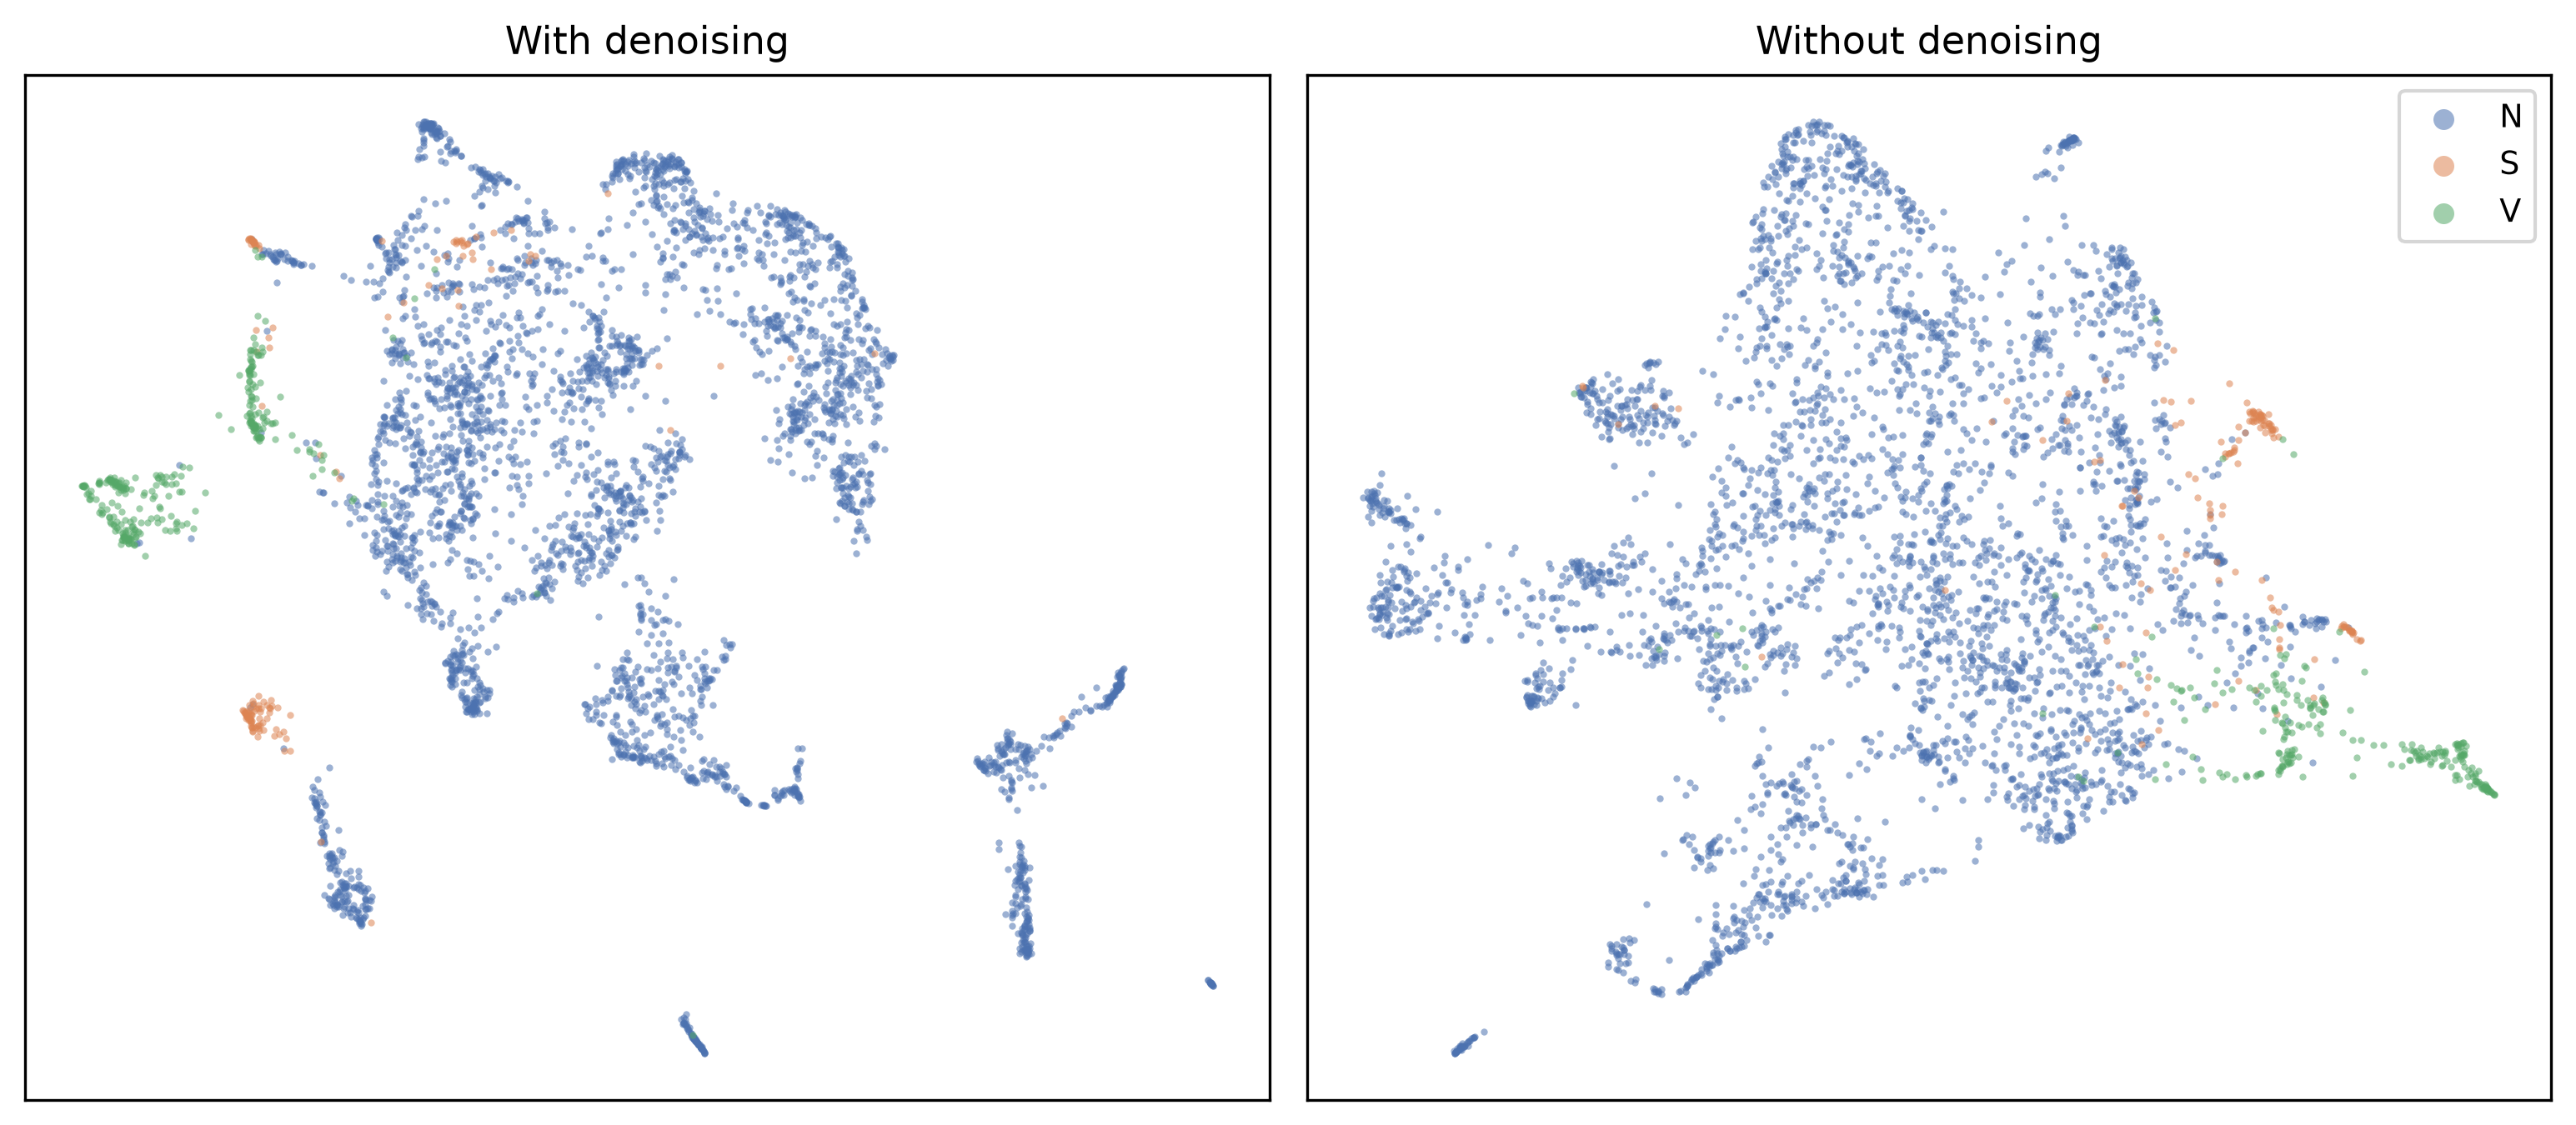

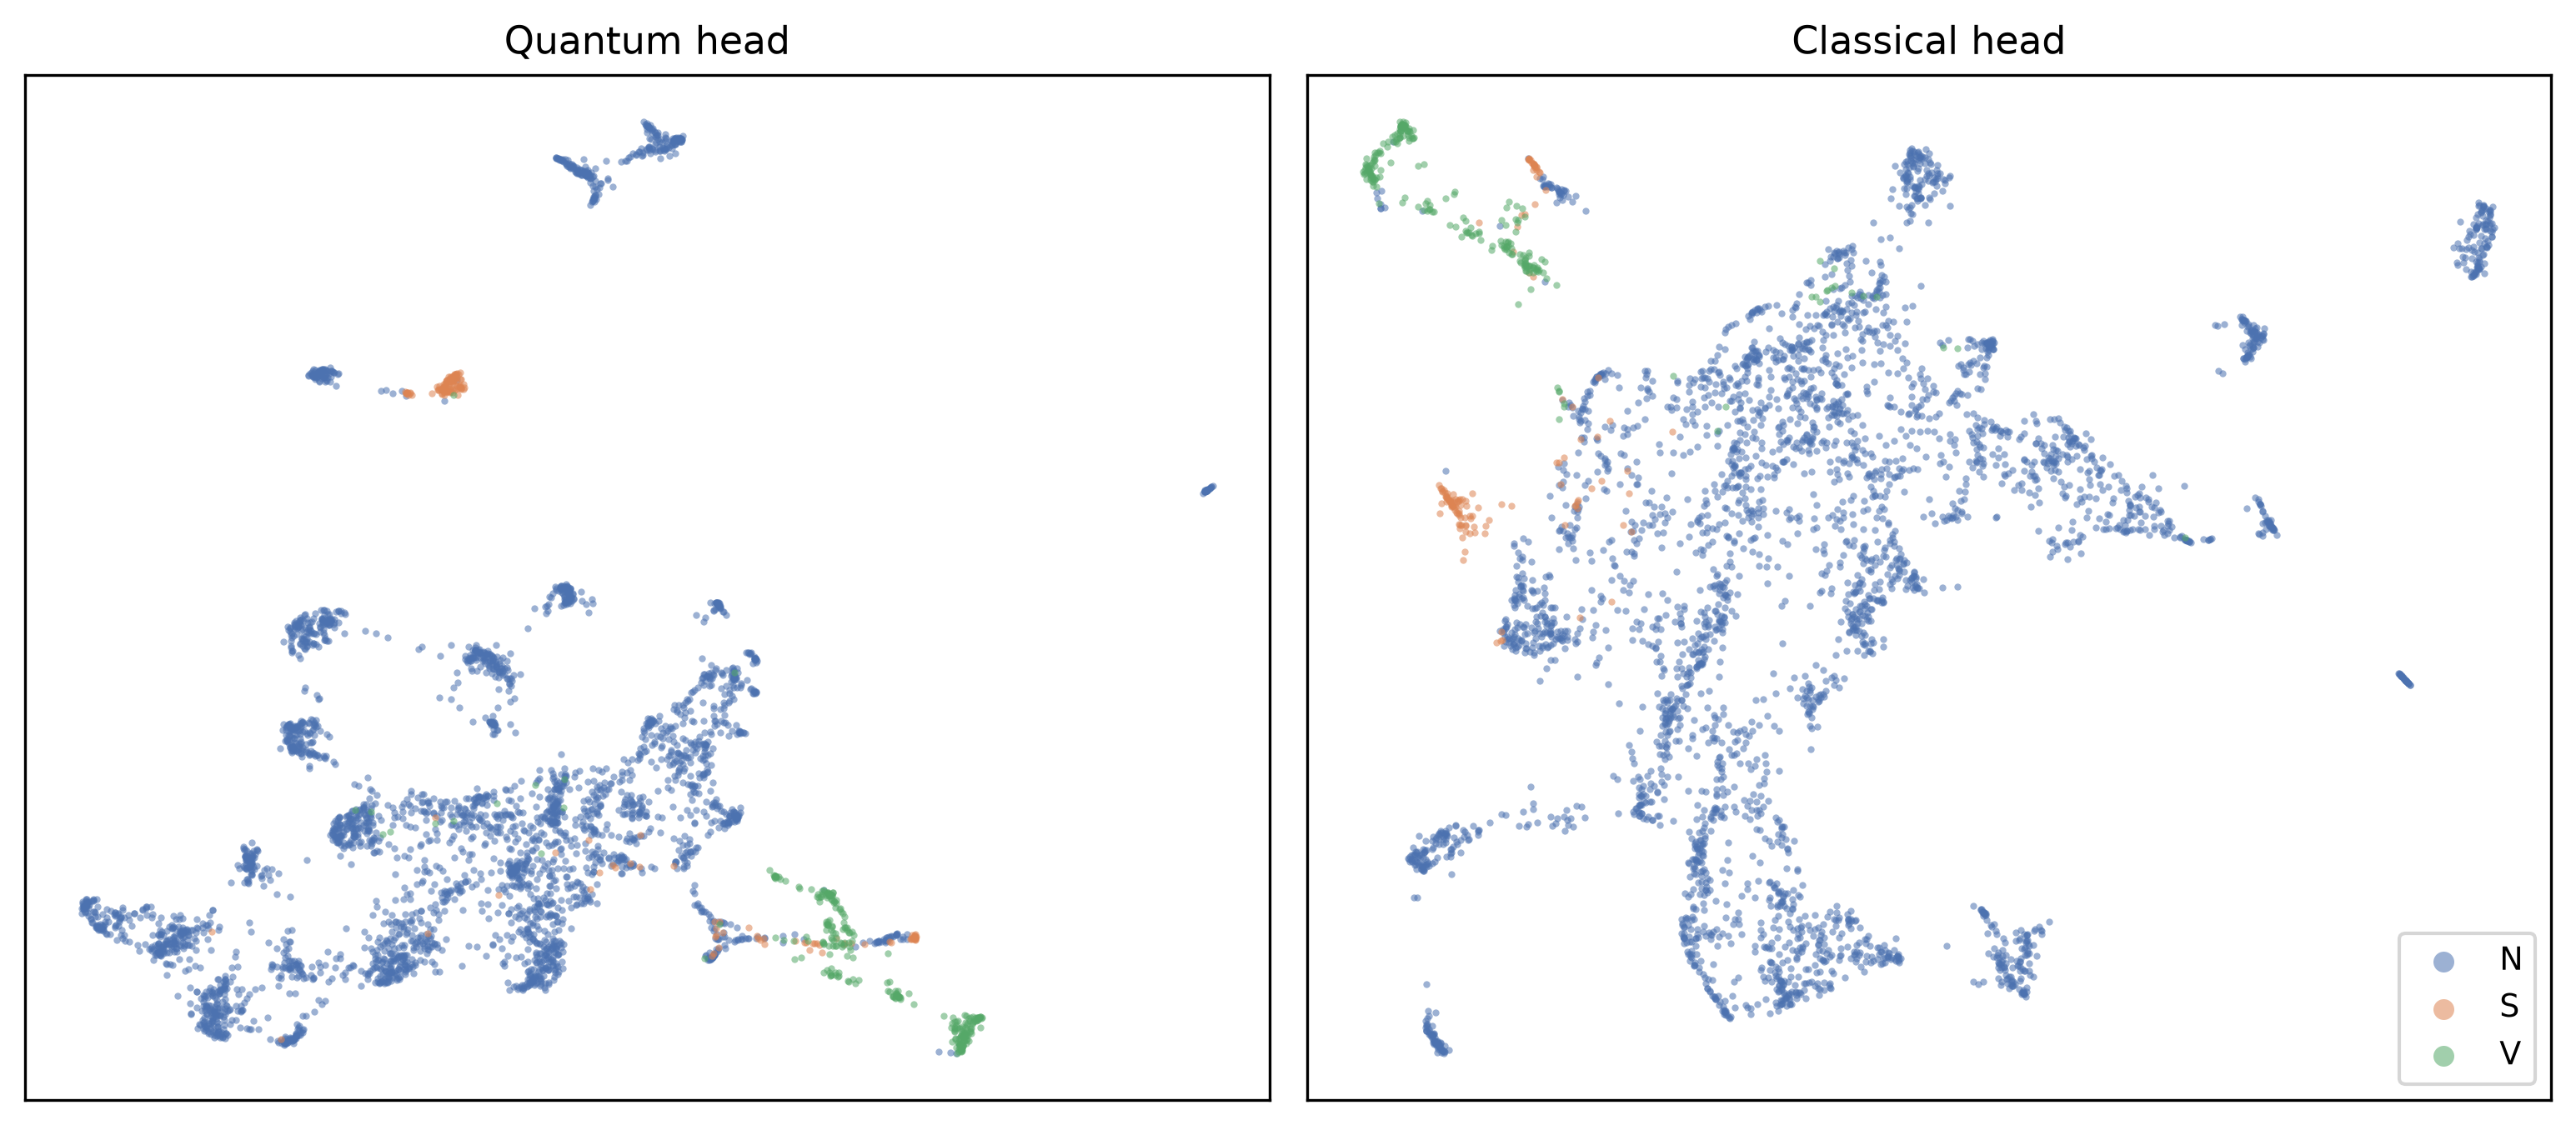

Da luu hinh vao d:\SPARC Lab\Denoise_ECG_BMELaB\runs_cls/_figures


: 

In [ ]:
# === UMAP: 2 hinh cho paper ===
os.makedirs('figures', exist_ok=True)

# Seed tot nhat cua tung head (doi theo ket qua muc 8a)
BEST_Q, BEST_C = 4, 4

jobs = [
    ('denoise', ['--run_dir', f'{R}/c09b_seed{BEST_C}', '--head', 'classical'],
     'figures/umap_denoise.png', 'Co vs KHONG khu nhieu (head classical)'),
    ('head',    ['--run_dir', f'{R}/q09_seed{BEST_Q}', '--run_dir_b', f'{R}/c09b_seed{BEST_C}'],
     'figures/umap_head.png',    'Head quantum vs classical'),
]

for mode, extra, out, desc in jobs:
    print(f'--- {desc} ---', flush=True)
    r = subprocess.run([sys.executable, 'scripts/plot_umap.py',
                        '--config', 'configs/default.yaml',
                        '--denoise_run', DENOISE_RUN,
                        '--device', DEVICE,
                        '--mode', mode, '--out', out] + extra,
                       env=ENV, capture_output=True, text=True)
    print(r.stdout.strip() if r.returncode == 0 else 'LOI:\n' + r.stderr[-1500:])

# Luu them 1 ban vao thu muc runs (R) de gom chung voi ket qua khac
import shutil
FIG = f'{R}/_figures'; os.makedirs(FIG, exist_ok=True)
from IPython.display import Image, display
for f in ['figures/umap_denoise.png', 'figures/umap_head.png']:
    if os.path.exists(f):
        shutil.copy(f, FIG)
        display(Image(f))
print('Da luu hinh vao', FIG)